# 03 — ChIP-seq at the *MEOX1* locus

This notebook supports **Fig. 5C**–style interpretation: **H3K27ac** (active chromatin) and **p65/RELA** (NF-κB subunit) ChIP-seq in **unstimulated human iPSC–derived cardiac fibroblasts** (Alexanian et al., *Nature* 2024). The biological focus is whether marks and factor binding are present around ***MEOX1***, linking chromatin state at this locus to the bulk RNA-seq story in notebook **02**.

**Run on: ARM64 (or any machine with the same R tools)** — FASTQs come from **`scripts/python/download_data.py`** (GEO **GSE221694** / SRR **22882100–22882105**). This track is **single-end** ChIP-seq, separate from **Cell Ranger** data.

**Scope here:** (1) check downloads, (2) align reads to **hg38** with **Rsubread** in **DNA** mode (same reference/index as notebook **02** when possible), (3) quantify read density in a fixed ***MEOX1*–centric window** with **featureCounts** + a small SAF, (4) optional **MACS2** peak-calling commands for full peak sets.

### Running this notebook

Use a Jupyter **R** kernel with **Rsubread** (and **ggplot2** for plots). Match **`INSTALL.md`** / **`environment.yml`**.

**Prerequisite:** Ensembl **GRCh38** primary assembly FASTA under **`data/reference/`**, and an Rsubread index **`hg38_ens110`** — easiest path is to run the reference cell in **`02_bulk_rnaseq_de.ipynb`** once.

Paths assume the notebook runs from **`notebooks/`** (`..` = project root).

**Optional (terminal):** [MACS2](https://github.com/macs3-project/MACS) for narrow peaks; [nf-core/chipseq](https://nf-co.re/chipseq) for a full QC pipeline (see **`STUDY_ANALYSIS_AND_REPLICATION_ROADMAP.md`**).

## Samples (six SRRs)

| SRR | Description (GEO label) |
|-----|-------------------------|
| **SRR22882100** | Input (early batch) |
| **SRR22882101** | H3K27ac replicate A |
| **SRR22882102** | H3K27ac replicate B |
| **SRR22882103** | RELA (p65) early |
| **SRR22882104** | Input (Nov 2022 batch) |
| **SRR22882105** | RELA (Nov 2022 batch) |

For **MACS2**, pair ChIPs with the **input from the same batch** (100 vs 101–103; **104** vs **105**). ENA may name the single FASTQ with or without **`_1`** in the filename; the code below picks **`.fastq.gz`** files automatically.

## Pipeline (compact)

1. **Index:** Reuse **`hg38_ens110`** on Ensembl **GRCh38** primary FASTA (build in **02** if missing).
2. **Align:** **Rsubread** `align` with **`type = "dna"`** (ChIP fragments; **single-end**).
3. **Locus quantification:** **featureCounts** with a one-line **SAF** window around ***MEOX1*** (rough **signal proxy**; not a substitute for peak calling or input normalization used in publication figures).
4. **Optional:** **MACS2** narrow peaks, **bigWig** coverage (e.g. deepTools), or **nf-core/chipseq** for production runs.

***MEOX1* coordinates (GRCh38):** the gene lies on chromosome **7** at **~157 Mb** (not ~27 Mb — that would be the wrong scale for human hg38). We use a **±250 kb** window around the Ensembl gene span so enhancers upstream/downstream are included.

In [1]:
# Check ChIP-seq FASTQs (R kernel)
chip_runs <- sprintf("SRR228821%02d", 0:5)
data_dir <- file.path("..", "data")
out_base <- file.path("..", "output", "chipseq")
bam_dir <- file.path(out_base, "bams")
dir.create(bam_dir, recursive = TRUE, showWarnings = FALSE)

find_chip_fastq <- function(run_id) {
  d <- file.path(data_dir, run_id)
  if (!dir.exists(d)) return(NA_character_)
  fq <- list.files(d, pattern = "\\.fastq\\.gz$", full.names = TRUE)
  if (length(fq) == 0) return(NA_character_)
  if (length(fq) == 1) return(fq)
  i <- grep("_1\\.fastq\\.gz$", fq)
  if (length(i)) fq[[i[1]]] else fq[[1]]
}

avail <- vapply(chip_runs, function(r) dir.exists(file.path(data_dir, r)), logical(1))
cat("ChIP run folders present:", sum(avail), "/ 6\n")
for (r in chip_runs[avail]) {
  fq <- find_chip_fastq(r)
  cat(r, ":", if (is.na(fq)) "no .fastq.gz" else basename(fq), "\n")
}

ChIP run folders present: 6 / 6
SRR22882100 : SRR22882100.fastq.gz 
SRR22882101 : SRR22882101.fastq.gz 
SRR22882102 : SRR22882102.fastq.gz 
SRR22882103 : SRR22882103.fastq.gz 
SRR22882104 : SRR22882104.fastq.gz 
SRR22882105 : SRR22882105.fastq.gz 


### Reference and index

Uses the same **`data/reference/`** layout as notebook **02**. If **`buildindex`** has not been run yet, execute the reference cell in **02** first (large download + one-time index build).

In [2]:
ref_dir <- file.path("..", "data", "reference")
fa_gz <- file.path(ref_dir, "Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz")
index_prefix <- file.path(ref_dir, "hg38_ens110")

if (!file.exists(fa_gz)) {
  stop("Missing ", fa_gz, " — run the hg38 download block in 02_bulk_rnaseq_de.ipynb")
}
if (!file.exists(paste0(index_prefix, ".00.b.tab"))) {
  stop("Missing Rsubread index files for ", index_prefix, " — run buildindex from 02_bulk_rnaseq_de.ipynb")
}
cat("FASTA:", fa_gz, "\nIndex:", index_prefix, "OK\n")

FASTA: ../data/reference/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz 
Index: ../data/reference/hg38_ens110 OK


### Align ChIP libraries (Rsubread, single-end DNA mode)

Outputs **`output/chipseq/bams/<SRR>.bam`**. Existing BAMs are skipped. **DNA** mode is appropriate for ChIP fragments (no splicing).

**Runtime:** similar order of magnitude to bulk RNA per library (depends on read count and CPU).

In [3]:
library(Rsubread)

nthreads <- max(1L, parallel::detectCores() - 1L)

for (run in chip_runs) {
  fq <- find_chip_fastq(run)
  if (is.na(fq) || !file.exists(fq)) next
  out_bam <- file.path(bam_dir, paste0(run, ".bam"))
  if (file.exists(out_bam)) {
    cat("Skip (exists):", run, "\n")
    next
  }
  message("Aligning ", run, " ...")
  align(
    index = index_prefix,
    readfile1 = fq,
    output_file = out_bam,
    nthreads = nthreads,
    type = "dna"
  )
}

bams <- list.files(bam_dir, pattern = "\\.bam$", full.names = TRUE)
cat("BAMs in", bam_dir, ":", length(bams), "\n")

Aligning SRR22882100 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (DNA-Seq)                                   ||
|| Input file    : SRR22882100.fastq.gz                                       ||
|| Output file   : SRR22882100.bam (BAM)                                      ||
|| Index name    : hg38_ens110                                                ||
||                                                  

Aligning SRR22882101 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (DNA-Seq)                                   ||
|| Input file    : SRR22882101.fastq.gz                                       ||
|| Output file   : SRR22882101.bam (BAM)                                      ||
|| Index name    : hg38_ens110                                                ||
||                                                  

Aligning SRR22882102 ...



...


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (DNA-Seq)                                   ||
|| Input file    : SRR22882103.fastq.gz                                       ||
|| Output file   : SRR22882103.bam (BAM)                                      ||
|| Index name    : hg38_ens110                                                ||
||                                                  

Aligning SRR22882104 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (DNA-Seq)                                   ||
|| Input file    : SRR22882104.fastq.gz                                       ||
|| Output file   : SRR22882104.bam (BAM)                                      ||
|| Index name    : hg38_ens110                                                ||
||                                                  

Aligning SRR22882105 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (DNA-Seq)                                   ||
|| Input file    : SRR22882105.fastq.gz                                       ||
|| Output file   : SRR22882105.bam (BAM)                                      ||
|| Index name    : hg38_ens110                                                ||
||                                                  

### Read counts in a *MEOX1*-centric window (featureCounts + SAF)

Ensembl **GRCh38** gene span for *MEOX1* is approximately **chr 7:157,168,805–157,181,219**; we extend **±250 kb** for regulatory context. SAF uses **Ensembl-style chromosome names** (**`7`**, not **`chr7`**) to match the Ensembl FASTA/index.

This gives **raw counts per library** overlapping the window — useful for teaching and quick checks. The code also computes **CPM** using **total reads in the featureCounts summary table** as the library size (see `fc$stat`). **Interpretation:** higher signal in H3K27ac/RELA vs matched input suggests enrichment; publication-style figures use **MACS2** (or nf-core) with **input** controls and peak calling.


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 6 BAM files                                      ||
||                                                                            ||
||                           SRR22882100.bam                                  ||
||                           SRR22882101.bam                                  ||
||                           SRR22882102.bam        

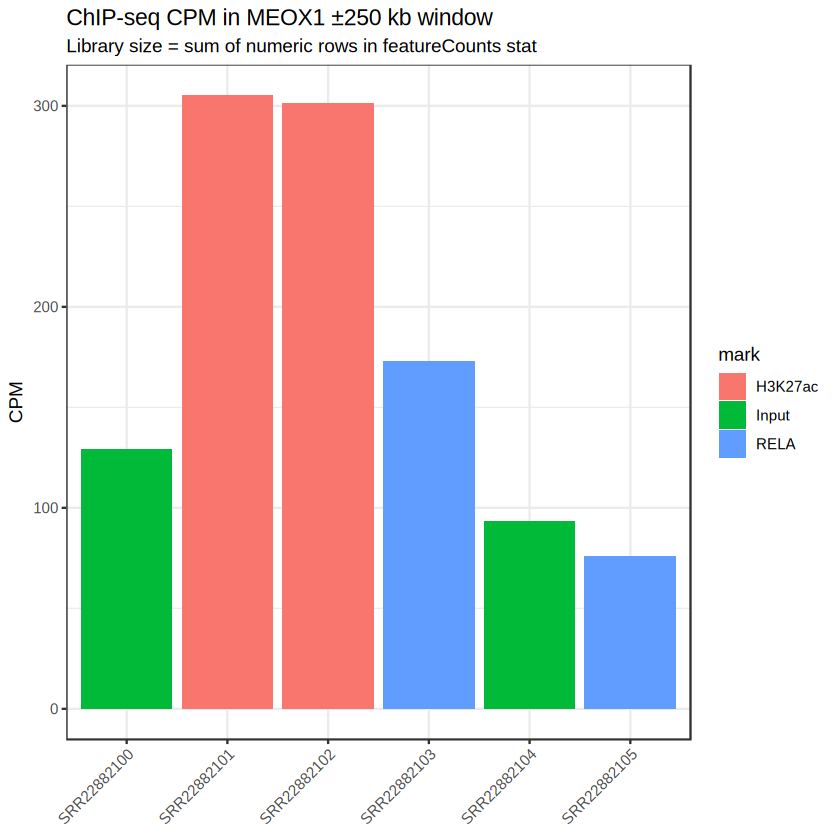

In [4]:
nthreads <- max(1L, parallel::detectCores() - 1L)

saf_path <- file.path(out_base, "MEOX1_locus.saf")
# GRCh38 ~157 Mb; 1-based inclusive coordinates for SAF
meox1_start <- 157168805L - 250000L
meox1_end <- 157181219L + 250000L
writeLines(
  c(
    "GeneID\tChr\tStart\tEnd\tStrand",
    paste("MEOX1_locus", "7", meox1_start, meox1_end, ".", sep = "\t")
  ),
  saf_path
)

bams <- sort(list.files(bam_dir, pattern = "\\.bam$", full.names = TRUE))
if (length(bams) == 0) {
  message("No BAMs — run the alignment cell above.")
} else {
  fc <- featureCounts(
    files = bams,
    annot.ext = saf_path,
    isGTFAnnotationFile = FALSE,
    isPairedEnd = FALSE,
    nthreads = nthreads
  )
  ct <- fc$counts
  colnames(ct) <- sub("\\.bam$", "", basename(colnames(ct)))
  cat("Counts in window:\n")
  print(as.integer(ct))

  st <- as.data.frame(fc$stat)
  num_cols <- names(st)[vapply(st, is.numeric, logical(1))]
  lib <- colSums(as.matrix(st[, num_cols, drop = FALSE]))
  names(lib) <- sub("\\.bam$", "", basename(names(lib)))
  lib <- lib[colnames(ct)]
  cpm <- as.numeric(ct) / pmax(lib, 1) * 1e6
  names(cpm) <- colnames(ct)
  cat("CPM in window (library size = sum of numeric rows in fc$stat per sample):\n")
  print(round(cpm, 2))

  run_order <- colnames(ct)
  mark_by_run <- c(
    SRR22882100 = "Input", SRR22882101 = "H3K27ac", SRR22882102 = "H3K27ac",
    SRR22882103 = "RELA", SRR22882104 = "Input", SRR22882105 = "RELA"
  )
  batch_by_run <- c(
    SRR22882100 = "early", SRR22882101 = "early", SRR22882102 = "early",
    SRR22882103 = "early", SRR22882104 = "Nov2022", SRR22882105 = "Nov2022"
  )
  meta <- data.frame(
    run = run_order,
    mark = mark_by_run[run_order],
    batch = batch_by_run[run_order],
    cpm = unname(cpm[run_order]),
    stringsAsFactors = FALSE
  )

  if (requireNamespace("ggplot2", quietly = TRUE)) {
    library(ggplot2)
    ggplot(meta, aes(x = run, y = cpm, fill = mark)) +
      geom_col() +
      theme_bw() +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      labs(
        title = "ChIP-seq CPM in MEOX1 ±250 kb window",
        subtitle = "Library size = sum of numeric rows in featureCounts stat",
        x = NULL, y = "CPM"
      )
  }
}

### Optional: MACS2 narrow peaks (run in a shell with MACS2 installed)

Example **paired input** contrasts (adjust paths to your BAMs):

```bash
# Early batch (from project root)
macs2 callpeak -t output/chipseq/bams/SRR22882101.bam output/chipseq/bams/SRR22882102.bam \\
  -c output/chipseq/bams/SRR22882100.bam -f BAM -g hs -n H3K27ac_early --outdir output/chipseq/macs2

macs2 callpeak -t output/chipseq/bams/SRR22882103.bam \\
  -c output/chipseq/bams/SRR22882100.bam -f BAM -g hs -n RELA_early --outdir output/chipseq/macs2

# Nov 2022 batch
macs2 callpeak -t output/chipseq/bams/SRR22882105.bam \\
  -c output/chipseq/bams/SRR22882104.bam -f BAM -g hs -n RELA_nov2022 --outdir output/chipseq/macs2
```

Inspect **`bed`** peaks overlapping ***MEOX1*** (chr7:157Mb) in IGV alongside published **Peak 9/10** annotations from the paper.

### Optional extensions

- **Merge BAMs** per mark with `samtools merge` before MACS2 for a single peak set per antibody.
- **SPMR bigWig** from MACS2 or **deepTools** `bamCoverage` for publication-style tracks.
- **csaw** / **DiffBind** (Bioconductor) for differential binding if you add more conditions.
- Cross-check locus choice with **Ensembl** or **UCSC** for the exact *MEOX1* build you use if you switch from **GRCh38**.